In [1]:
import os
import sys

sys.path.append(os.path.abspath('..'))

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"
os.environ["JAX_DEFAULT_MATMUL_PRECISION"] = "highest"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_cpu_multi_thread_eigen=false intra_op_parallelism_threads=1"
os.environ["MUJOCO_GL"] = 'egl'
import argparse
import random
import shutil
from datetime import datetime
from typing import Optional

import numpy as np
import torch
import tqdm


# Metra env
from flash_rl.envs.envs.mujoco.ant_env import AntEnv
metra_env = AntEnv(render_hw=100)

In [2]:
import random
import gym
import numpy as np
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torch.distributions import Normal
import matplotlib.pyplot as plt

class PolicyNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim, action_bound):
        super(PolicyNetContinuous, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc_mu = torch.nn.Linear(hidden_dim, action_dim)
        self.fc_std = torch.nn.Linear(hidden_dim, action_dim)
        self.action_bound = action_bound

    def forward(self, x):
        x = F.relu(self.fc1(x))
        mu = self.fc_mu(x)
        std = F.softplus(self.fc_std(x))
        dist = Normal(mu, std)
        normal_sample = dist.rsample()  # rsample()是重参数化采样
        log_prob = dist.log_prob(normal_sample)
        action = torch.tanh(normal_sample)
        # 计算tanh_normal分布的对数概率密度
        log_prob = log_prob - torch.log(1 - torch.tanh(action).pow(2) + 1e-7)
        action = action * self.action_bound
        return action, log_prob


class QValueNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(QValueNetContinuous, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, a):
        cat = torch.cat([x, a], dim=1)
        x = F.relu(self.fc1(cat))
        x = F.relu(self.fc2(x))
        return self.fc_out(x)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
class SACContinuous:
    """连续动作SAC（支持多维动作）"""
    def __init__(
        self,
        state_dim,
        hidden_dim,
        action_dim,
        action_bound,
        actor_lr,
        critic_lr,
        alpha_lr,
        target_entropy,
        tau,
        gamma,
        device,
    ):
        self.actor = PolicyNetContinuous(
            state_dim, hidden_dim, action_dim, action_bound
        ).to(device)
        self.critic_1 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.critic_2 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.target_critic_1 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.target_critic_2 = QValueNetContinuous(state_dim, hidden_dim, action_dim).to(device)

        self.target_critic_1.load_state_dict(self.critic_1.state_dict())
        self.target_critic_2.load_state_dict(self.critic_2.state_dict())

        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_1_optimizer = torch.optim.Adam(self.critic_1.parameters(), lr=critic_lr)
        self.critic_2_optimizer = torch.optim.Adam(self.critic_2.parameters(), lr=critic_lr)

        self.log_alpha = torch.tensor(np.log(0.01), dtype=torch.float32, device=device, requires_grad=True)
        self.log_alpha_optimizer = torch.optim.Adam([self.log_alpha], lr=alpha_lr)

        self.target_entropy = float(target_entropy)
        self.gamma = float(gamma)
        self.tau = float(tau)
        self.device = device
        self.action_dim = int(action_dim)

    def _ensure_batch(self, x):
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32, device=self.device)
        elif not torch.is_tensor(x):
            x = torch.tensor(np.asarray(x), dtype=torch.float32, device=self.device)
        else:
            x = x.to(self.device, dtype=torch.float32)
        if x.ndim == 1:
            x = x.unsqueeze(0)
        return x

    def take_action(self, state, training=True):
        state = self._ensure_batch(state)
        with torch.no_grad():
            action, _ = self.actor(state)
        return action.squeeze(0).cpu().numpy().astype(np.float32)

    def calc_target(self, rewards, next_states, dones):
        next_actions, next_log_prob = self.actor(next_states)
        # 汇总动作维度上的log_prob，得到(B,1)
        next_log_prob = torch.sum(next_log_prob, dim=-1, keepdim=True)
        q1_value = self.target_critic_1(next_states, next_actions)
        q2_value = self.target_critic_2(next_states, next_actions)
        next_value = torch.min(q1_value, q2_value) - self.log_alpha.exp() * next_log_prob
        td_target = rewards + self.gamma * next_value * (1.0 - dones)
        return td_target

    def soft_update(self, net, target_net):
        for param_target, param in zip(target_net.parameters(), net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) + param.data * self.tau)

    def update(self, transition_dict):
        states = self._ensure_batch(transition_dict["states"])
        actions = self._ensure_batch(transition_dict["actions"])
        rewards = self._ensure_batch(transition_dict["rewards"])
        next_states = self._ensure_batch(transition_dict["next_states"])
        dones = self._ensure_batch(transition_dict["dones"])

        td_target = self.calc_target(rewards, next_states, dones)

        q1_pred = self.critic_1(states, actions)
        q2_pred = self.critic_2(states, actions)
        critic_1_loss = F.mse_loss(q1_pred, td_target.detach())
        critic_2_loss = F.mse_loss(q2_pred, td_target.detach())

        self.critic_1_optimizer.zero_grad()
        critic_1_loss.backward()
        self.critic_1_optimizer.step()

        self.critic_2_optimizer.zero_grad()
        critic_2_loss.backward()
        self.critic_2_optimizer.step()

        new_actions, log_prob = self.actor(states)
        log_prob = torch.sum(log_prob, dim=-1, keepdim=True)
        q1_value = self.critic_1(states, new_actions)
        q2_value = self.critic_2(states, new_actions)
        min_q = torch.min(q1_value, q2_value)
        actor_loss = (self.log_alpha.exp() * log_prob - min_q).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        self.log_alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.log_alpha_optimizer.step()

        self.soft_update(self.critic_1, self.target_critic_1)
        self.soft_update(self.critic_2, self.target_critic_2)

        return {
            "critic_1_loss": float(critic_1_loss.item()),
            "critic_2_loss": float(critic_2_loss.item()),
            "actor_loss": float(actor_loss.item()),
            "alpha_loss": float(alpha_loss.item()),
            "alpha": float(self.log_alpha.exp().item()),
            "q_mean": float(min_q.mean().item()),
            "log_prob_mean": float(log_prob.mean().item()),
        }

    def sample_actions(self, step, prev_transtion, training=False):
        return self.take_action(prev_transtion["next_observation"], training=training)[None, :]

In [4]:
actor_lr = 3e-4
critic_lr = 3e-3
alpha_lr = 3e-4
num_episodes = 100

hidden_dim = 1024
gamma = 0.99
tau = 0.005  # 软更新参数
buffer_size = 100000
minimal_size = 1000
batch_size = 256

state_dim = 29
skill_dim = 2

action_dim = metra_env.action_space.shape[0]

action_bound = metra_env.action_space.high[0]


target_entropy = -metra_env.action_space.shape[0]
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

agent_obs_dim = state_dim + skill_dim
agent = SACContinuous(agent_obs_dim, hidden_dim, action_dim, action_bound,
                      actor_lr, critic_lr, alpha_lr, target_entropy, tau,
                      gamma, device)


In [5]:
skill_encoder_hidden_dim = 1024
skill_encoder_num_layers = 2
encoder_lr = 1e-4
lambda_lr = 1e-4
lambda_init_value = 30
# ============================ Initialize encoder ============================

from flash_rl.agents.metra.network import SkillGEncoder, FlashSACTemperature
from flash_rl.agents.metra.metra_comp import gen_optimizer
from flash_rl.agents.utils.network import Network


skill_encoder_net = SkillGEncoder(
    input_dim=state_dim,
    output_dim=skill_dim,
    hidden_sizes=[skill_encoder_hidden_dim] * skill_encoder_num_layers,
).to(device)

skill_encoder_optimizer, skill_encoder_scheduler = gen_optimizer(
    parameters=skill_encoder_net.parameters(),
    use_fused=False,
    scheduler_type="constant",
    init_value=None,
    peak=encoder_lr,
    end_value=None,
    warmup_steps=None,
    decay_steps=None
)
skill_encoder = Network(
    network=skill_encoder_net,
    optimizer=skill_encoder_optimizer,
    scheduler=skill_encoder_scheduler,
    compile_network=False,
    compile_mode=None,
    use_weight_normalization=False,
)



dual_lambda_net = FlashSACTemperature(lambda_init_value).to(device)
dual_lambda_optimizer, dual_lambda_scheduler = gen_optimizer(
    parameters=dual_lambda_net.parameters(),
    use_fused=False,
    scheduler_type="constant",
    init_value=None,
    peak=lambda_lr,
    end_value=None,
    warmup_steps=None,
    decay_steps=None
)
dual_lambda = Network(
    network=dual_lambda_net,
    optimizer=dual_lambda_optimizer,
    scheduler=dual_lambda_scheduler,
    compile_network=False,
    compile_mode=None,
    use_weight_normalization=False,
)


In [6]:
from flash_rl.buffers.metra_buffer import METRATorchBuffer

replay_buffer = METRATorchBuffer(
    None,
    metra_env.action_space,
    n_step=1,
    gamma=0.99,
    max_length=300000,
    min_length=1000,
    sample_batch_size=256,
    device_type=device.type,
    skill_dim=skill_dim,
 )

from dataclasses import dataclass

@dataclass
class CFG:
    max_path_length: int = 200

cfg = CFG()

def sample_skill(skill_dim, skill_type="continuous"):
    if skill_type == "discrete":
        idx = np.random.randint(0, skill_dim)
        onehot = np.zeros(skill_dim, dtype=np.float32)
        onehot[idx] = 1.0
        return onehot
    skill = np.random.randn(skill_dim).astype(np.float32)
    norm = np.linalg.norm(skill) + 1e-8
    return skill / norm

joint_train: 100%|██████████| 40/40 [00:20<00:00,  1.98it/s]


,reward_abs_mean,reward_mean,squared_dist_mean,constraint_mean,encoder_loss,dual_lambda,dual_lambda_loss,critic_1_loss,critic_2_loss,actor_loss,alpha_loss,alpha,q_mean,log_prob_mean,episode,episode_length,episode_env_return,buffer_size
30,0.284925,0.003922,0.118589,0.000989,-0.024646,24.848869,0.003065,0.046487,0.052720,-2.088887,-278.914511,0.005103,1.859978,-44.847549,30,200,-563.717540,179800
31,0.266962,0.004625,0.103417,0.001000,-0.026045,24.692190,0.003171,0.045329,0.054120,-2.115471,-281.844484,0.004995,1.889671,-45.188584,31,200,-515.922043,185600
32,0.251453,0.007339,0.097102,0.000969,-0.026475,24.542255,0.002879,0.051398,0.057833,-2.147983,-284.931902,0.004890,1.925119,-45.556868,32,200,-640.131945,191400
33,0.273625,0.008651,0.117014,0.000981,-0.029103,24.394741,0.003050,0.047424,0.054113,-2.182462,-287.613823,0.004788,1.962881,-45.846654,33,200,-632.259396,197200
34,0.281133,0.005465,0.121637,0.000998,-0.026080,24.241927,0.003103,0.043643,0.048625,-2.206000,-290.002286,0.004688,1.989912,-46.080052,34,200,-635.682466,203000
35,0.261821,0.005940,0.101886,0.001000,-0.026166,24.091401,0.003039,0.044108,0.048137,-2.243351,-293.049264,0.004590,2.030141,-46.434400,35,200,-518.112003,208800
36,0.252895,0.003576,0.097836,0.001000,-0.024251,23.939979,0.003113,0.038936,0.042016,-2.263218,-295.505044,0.004495,2.053354,-46.676958,36,200,-650.907850,214600
37,0.247794,0.004513,0.092771,0.000997,-0.024889,23.788711,0.003096,0.036766,0.041370,-2.288105,-298.037877,0.004401,2.081474,-46.932361,37,200,-631.748710,220400
38,0.270089,0.006656,0.109802,0.001000,-0.026742,23.638183,0.003065,0.035584,0.037313,-2.339786,-300.566823,0.004310,2.136343,-47.185545,38,200,-474.289609,226200
39,0.268271,0.006362,0.113184,0.001000,-0.026336,23.489423,0.003074,0.038388,0.040674,-2.364071,-303.048437,0.004221,2.163810,-47.428544,39,200,-590.639234,232000


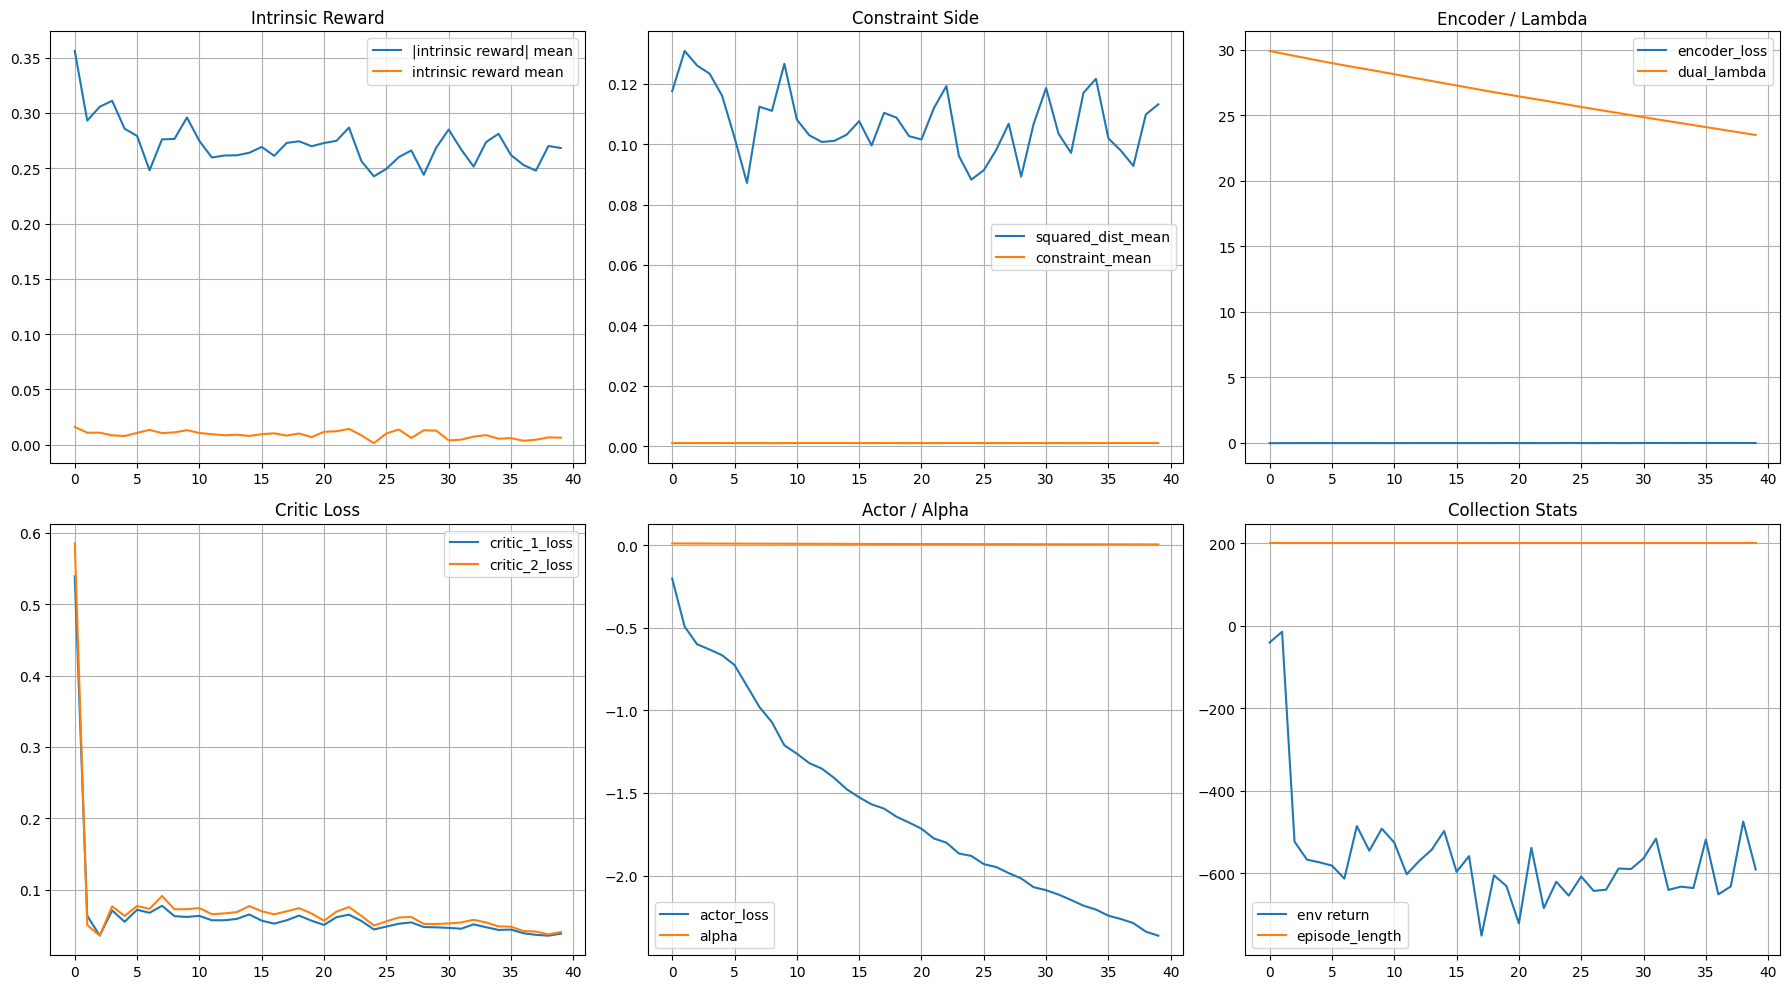

,reward_abs_mean,reward_mean,squared_dist_mean,constraint_mean,encoder_loss,dual_lambda,dual_lambda_loss,critic_1_loss,critic_2_loss,actor_loss,alpha_loss,alpha,q_mean,log_prob_mean,episode,episode_length,episode_env_return,buffer_size
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.0,40.000000,40.000000
mean,0.271901,0.009132,0.107019,0.000993,-0.031356,26.579734,0.003123,0.066245,0.074256,-1.587789,-234.645121,0.006632,1.348685,-38.094464,19.500000,200.0,-561.304827,118900.000000
std,0.020704,0.003268,0.010941,0.000011,0.004186,1.916905,0.000128,0.077385,0.083850,0.586428,53.145819,0.001696,0.586092,8.583303,11.690452,0.0,138.669841,67804.621278
min,0.242628,0.001422,0.087136,0.000949,-0.040533,23.489423,0.002814,0.035584,0.035695,-2.364071,-303.048437,0.004221,0.070945,-47.428544,0.000000,200.0,-751.123423,5800.000000
25%,0.260900,0.006805,0.100428,0.000992,-0.034275,24.962496,0.003068,0.047055,0.052013,-2.075266,-276.729011,0.005185,0.975893,-44.592300,9.750000,200.0,-631.876382,62350.000000
50%,0.269551,0.009269,0.106737,0.000997,-0.032213,26.516308,0.003118,0.055549,0.063248,-1.698053,-245.814594,0.006398,1.437827,-40.661251,19.500000,200.0,-588.935065,118900.000000
75%,0.277152,0.010969,0.113905,0.001000,-0.026849,28.170929,0.003205,0.063008,0.072601,-1.249866,-205.529633,0.007939,1.843994,-34.501738,29.250000,200.0,-535.017152,175450.000000
max,0.356008,0.016106,0.130867,0.001000,-0.024219,29.903529,0.003370,0.539134,0.585275,-0.202988,-98.588419,0.009897,2.163810,-13.357351,39.000000,200.0,-14.196327,232000.000000


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from flash_rl.agents.metra.metra_comp import compute_metra_intrinsic_reward, compute_metra_constraint

# -------------------------- Joint SAC + Encoder Training --------------------------
num_train_episodes = 40
updates_per_episode = 64
warmup_random_steps = 2 * cfg.max_path_length
skill_type = "continuous"
constraint_epsilon = 1e-3

def _as_single_obs(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim > 1:
        return x[0].astype(np.float32)
    return x.astype(np.float32)

def collect_one_episode(env, sac_agent, buffer, skill_dim, max_path_length, *, random_until=0, global_step=0):
    obs, _ = env.reset()
    obs = _as_single_obs(obs)
    skill = sample_skill(skill_dim, skill_type=skill_type)

    ep_env_return = 0.0
    ep_len = 0

    for t in range(max_path_length):
        aug_obs = np.concatenate([obs, skill], axis=-1).astype(np.float32)
        if global_step < random_until:
            action = env.action_space.sample().astype(np.float32)
        else:
            action = sac_agent.take_action(aug_obs, training=True)

        next_obs, reward, terminated, truncated, info = env.step(action)
        next_obs = _as_single_obs(next_obs)
        done = bool(terminated or truncated)

        next_obs_for_buffer = next_obs.copy()
        if done and isinstance(info, dict) and "final_obs" in info:
            try:
                final_obs = _as_single_obs(info["final_obs"])
                if final_obs.shape[-1] == obs.shape[-1]:
                    next_obs_for_buffer = final_obs
            except Exception:
                pass

        transition = {
            "observation": obs,
            "action": action,
            "reward": np.float32(reward),
            "terminated": np.float32(terminated),
            "truncated": np.float32(truncated),
            "next_observation": next_obs_for_buffer,
            "skill": skill.astype(np.float32),
            "skill_resample_step": np.int64(t),
        }
        buffer.add(transition)

        ep_env_return += float(reward)
        ep_len += 1
        global_step += 1
        obs = next_obs

        if done:
            break

    return ep_len, ep_env_return, global_step

def encoder_dual_update_from_batch(batch):
    obs = batch["observation"].to(device)
    next_obs = batch["next_observation"].to(device)
    skills = batch["skill"].to(device)

    encoder_in = torch.cat([obs, next_obs], dim=0)
    features = skill_encoder(observations=encoder_in, training=True)
    cur_feat, next_feat = torch.chunk(features, 2, dim=0)

    intrinsic_reward, squared_dist = compute_metra_intrinsic_reward(
        current_features=cur_feat,
        next_features=next_feat,
        skills=skills,
        skill_type=skill_type,
    )
    constraint_term = compute_metra_constraint(
        squared_distance=squared_dist,
        epsilon=constraint_epsilon,
    )

    lambda_value = dual_lambda().detach()
    encoder_objective = intrinsic_reward + lambda_value * constraint_term
    encoder_loss = -encoder_objective.mean()

    assert skill_encoder.optimizer is not None
    skill_encoder.optimizer.zero_grad(set_to_none=True)
    encoder_loss.backward()
    skill_encoder.optimizer.step()
    if skill_encoder.scheduler is not None:
        skill_encoder.scheduler.step()

    with torch.no_grad():
        cst_mean = constraint_term.detach().mean()
    log_lambda = dual_lambda.network.log_temp
    dual_lambda_loss = log_lambda * cst_mean

    assert dual_lambda.optimizer is not None
    dual_lambda.optimizer.zero_grad(set_to_none=True)
    dual_lambda_loss.backward()
    dual_lambda.optimizer.step()
    if dual_lambda.scheduler is not None:
        dual_lambda.scheduler.step()

    with torch.no_grad():
        eval_features = skill_encoder(observations=encoder_in, training=False)
        eval_cur, eval_next = torch.chunk(eval_features, 2, dim=0)
        intrinsic_reward_eval, squared_dist_eval = compute_metra_intrinsic_reward(
            current_features=eval_cur,
            next_features=eval_next,
            skills=skills,
            skill_type=skill_type,
        )
        constraint_eval = compute_metra_constraint(
            squared_distance=squared_dist_eval,
            epsilon=constraint_epsilon,
        )

    return {
        "intrinsic_reward": intrinsic_reward_eval.detach().unsqueeze(-1),
        "reward_abs_mean": float(intrinsic_reward_eval.abs().mean().item()),
        "reward_mean": float(intrinsic_reward_eval.mean().item()),
        "squared_dist_mean": float(squared_dist_eval.mean().item()),
        "constraint_mean": float(constraint_eval.mean().item()),
        "encoder_loss": float(encoder_loss.item()),
        "dual_lambda": float(dual_lambda().detach().item()),
        "dual_lambda_loss": float(dual_lambda_loss.item()),
    }

def sac_update_with_intrinsic(batch, intrinsic_reward):
    obs = batch["observation"].to(device)
    next_obs = batch["next_observation"].to(device)
    skills = batch["skill"].to(device)

    states = torch.cat([obs, skills], dim=-1)
    next_states = torch.cat([next_obs, skills], dim=-1)
    dones = torch.maximum(batch["terminated"], batch["truncated"]).to(device).unsqueeze(-1)

    transition_dict = {
        "states": states,
        "actions": batch["action"].to(device),
        "rewards": intrinsic_reward.to(device),
        "next_states": next_states,
        "dones": dones,
    }
    return agent.update(transition_dict)

_seed = 0
random.seed(_seed)
np.random.seed(_seed)
torch.manual_seed(_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(_seed)

replay_buffer.reset()
train_logs = []
global_step = 0

for ep in tqdm(range(num_train_episodes), desc="joint_train"):
    ep_len, ep_env_return, global_step = collect_one_episode(
        metra_env,
        agent,
        replay_buffer,
        skill_dim,
        cfg.max_path_length,
        random_until=warmup_random_steps,
        global_step=global_step,
    )

    update_records = []
    if replay_buffer.can_sample():
        for _ in range(updates_per_episode):
            batch = replay_buffer.sample()
            enc_info = encoder_dual_update_from_batch(batch)
            sac_info = sac_update_with_intrinsic(batch, enc_info["intrinsic_reward"])
            update_records.append({**enc_info, **sac_info})

    if len(update_records) > 0:
        ep_stats = {k: float(np.mean([rec[k] for rec in update_records])) for k in update_records[0].keys() if k != "intrinsic_reward"}
    else:
        ep_stats = {
            "reward_abs_mean": np.nan,
            "reward_mean": np.nan,
            "squared_dist_mean": np.nan,
            "constraint_mean": np.nan,
            "encoder_loss": np.nan,
            "dual_lambda": float(dual_lambda().detach().item()),
            "dual_lambda_loss": np.nan,
            "critic_1_loss": np.nan,
            "critic_2_loss": np.nan,
            "actor_loss": np.nan,
            "alpha_loss": np.nan,
            "alpha": float(agent.log_alpha.exp().item()),
            "q_mean": np.nan,
            "log_prob_mean": np.nan,
        }

    ep_stats.update({
        "episode": ep,
        "episode_length": ep_len,
        "episode_env_return": ep_env_return,
        "buffer_size": len(replay_buffer),
    })
    train_logs.append(ep_stats)

train_df = pd.DataFrame(train_logs)
display(train_df.tail(10))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

axes[0].plot(train_df["episode"], train_df["reward_abs_mean"], label="|intrinsic reward| mean")
axes[0].plot(train_df["episode"], train_df["reward_mean"], label="intrinsic reward mean")
axes[0].set_title("Intrinsic Reward")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(train_df["episode"], train_df["squared_dist_mean"], label="squared_dist_mean")
axes[1].plot(train_df["episode"], train_df["constraint_mean"], label="constraint_mean")
axes[1].set_title("Constraint Side")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(train_df["episode"], train_df["encoder_loss"], label="encoder_loss")
axes[2].plot(train_df["episode"], train_df["dual_lambda"], label="dual_lambda")
axes[2].set_title("Encoder / Lambda")
axes[2].grid(True)
axes[2].legend()

axes[3].plot(train_df["episode"], train_df["critic_1_loss"], label="critic_1_loss")
axes[3].plot(train_df["episode"], train_df["critic_2_loss"], label="critic_2_loss")
axes[3].set_title("Critic Loss")
axes[3].grid(True)
axes[3].legend()

axes[4].plot(train_df["episode"], train_df["actor_loss"], label="actor_loss")
axes[4].plot(train_df["episode"], train_df["alpha"], label="alpha")
axes[4].set_title("Actor / Alpha")
axes[4].grid(True)
axes[4].legend()

axes[5].plot(train_df["episode"], train_df["episode_env_return"], label="env return")
axes[5].plot(train_df["episode"], train_df["episode_length"], label="episode_length")
axes[5].set_title("Collection Stats")
axes[5].grid(True)
axes[5].legend()

plt.tight_layout()
plt.show()

train_df.describe(include="all")

In [8]:
result_cols = [
    "episode",
    "reward_abs_mean",
    "reward_mean",
    "squared_dist_mean",
    "constraint_mean",
    "encoder_loss",
    "dual_lambda",
    "critic_1_loss",
    "critic_2_loss",
    "actor_loss",
    "alpha",
    "q_mean",
    "episode_env_return",
    "episode_length",
    "buffer_size",
]

summary_tail = train_df[result_cols].tail(5).copy()
display(summary_tail)

print("\nFinal row:")
print(summary_tail.iloc[-1].to_dict())

,episode,reward_abs_mean,reward_mean,squared_dist_mean,constraint_mean,encoder_loss,dual_lambda,critic_1_loss,critic_2_loss,actor_loss,alpha,q_mean,episode_env_return,episode_length,buffer_size
35,35,0.261821,0.005940,0.101886,0.001000,-0.026166,24.091401,0.044108,0.048137,-2.243351,0.004590,2.030141,-518.112003,200,208800
36,36,0.252895,0.003576,0.097836,0.001000,-0.024251,23.939979,0.038936,0.042016,-2.263218,0.004495,2.053354,-650.907850,200,214600
37,37,0.247794,0.004513,0.092771,0.000997,-0.024889,23.788711,0.036766,0.041370,-2.288105,0.004401,2.081474,-631.748710,200,220400
38,38,0.270089,0.006656,0.109802,0.001000,-0.026742,23.638183,0.035584,0.037313,-2.339786,0.004310,2.136343,-474.289609,200,226200
39,39,0.268271,0.006362,0.113184,0.001000,-0.026336,23.489423,0.038388,0.040674,-2.364071,0.004221,2.163810,-590.639234,200,232000



Final row:
{'episode': 39.0, 'reward_abs_mean': 0.26827148883603513, 'reward_mean': 0.006361548508721171, 'squared_dist_mean': 0.11318420001771301, 'constraint_mean': 0.0010000000474974513, 'encoder_loss': -0.026336335671658162, 'dual_lambda': 23.489423006772995, 'critic_1_loss': 0.03838809602893889, 'critic_2_loss': 0.04067386966198683, 'actor_loss': -2.3640712574124336, 'alpha': 0.004221044000587426, 'q_mean': 2.163809511810541, 'episode_env_return': -590.6392338412153, 'episode_length': 200.0, 'buffer_size': 232000.0}


standard_metra_train:   0%|          | 0/35 [00:00<?, ?it/s]/tmp/ipykernel_185517/2287445962.py:224: RuntimeWarning: Mean of empty slice
  "actor_loss_mean": float(np.nanmean(actor_losses)),
/tmp/ipykernel_185517/2287445962.py:225: RuntimeWarning: Mean of empty slice
  "actor_entropy_mean": float(np.nanmean(actor_entropies)),
/tmp/ipykernel_185517/2287445962.py:226: RuntimeWarning: Mean of empty slice
  "critic_loss_mean": float(np.nanmean(critic_losses)),
standard_metra_train: 100%|██████████| 35/35 [00:22<00:00,  1.53it/s]


,episode,episode_length,episode_env_return,buffer_size,actor_loss_mean,actor_entropy_mean,critic_loss_mean,alpha_mean,collapse_ratio,mean_action_std,mean_action_abs,mean_displacement,mean_path_length
25,25,200.0,-219.993208,5200.0,-0.424429,-1.943048,0.017055,0.007256,0.0,0.102685,0.631960,0.323041,0.984429
26,26,200.0,-178.989047,5400.0,-0.428106,-2.338696,0.015174,0.007203,NaN,NaN,NaN,NaN,NaN
27,27,200.0,-89.812803,5600.0,-0.376017,-0.491787,0.017753,0.007095,NaN,NaN,NaN,NaN,NaN
28,28,200.0,-178.028843,5800.0,-0.412410,-1.691269,0.021335,0.006978,NaN,NaN,NaN,NaN,NaN
29,29,200.0,-147.313305,6000.0,-0.450991,-2.259313,0.023088,0.006898,NaN,NaN,NaN,NaN,NaN
30,30,200.0,-314.302832,6200.0,-0.455969,-2.323864,0.019360,0.006839,0.0,0.089380,0.646782,0.251629,0.568781
31,31,200.0,-249.643916,6400.0,-0.427980,-1.279764,0.021070,0.006754,NaN,NaN,NaN,NaN,NaN
32,32,200.0,-255.901076,6600.0,-0.401210,-2.276228,0.018289,0.006668,NaN,NaN,NaN,NaN,NaN
33,33,200.0,-256.281291,6800.0,-0.418078,-3.317967,0.015627,0.006624,NaN,NaN,NaN,NaN,NaN
34,34,200.0,-137.267134,7000.0,-0.419428,-1.899457,0.018370,0.006578,0.0,0.075487,0.599392,0.265069,0.542267


,skill_id,num_steps,mean_action_std,mean_action_abs,displacement,path_length,is_static,episode
48,0,200,0.073705,0.657376,0.533902,0.602871,False,30
49,1,200,0.077127,0.605443,0.110295,0.512449,False,30
50,2,200,0.063203,0.527582,0.074816,0.600588,False,30
51,3,200,0.103496,0.562930,0.287651,1.129410,False,30
52,4,200,0.092058,0.702620,0.452138,0.697618,False,30
53,5,200,0.113545,0.697066,0.038678,0.174334,False,30
54,6,200,0.118782,0.729952,0.406066,0.583592,False,30
55,7,200,0.073128,0.691283,0.109484,0.249386,False,30
56,0,200,0.067604,0.662785,0.377653,0.476708,False,34
57,1,200,0.078496,0.460976,0.044737,0.190475,False,34


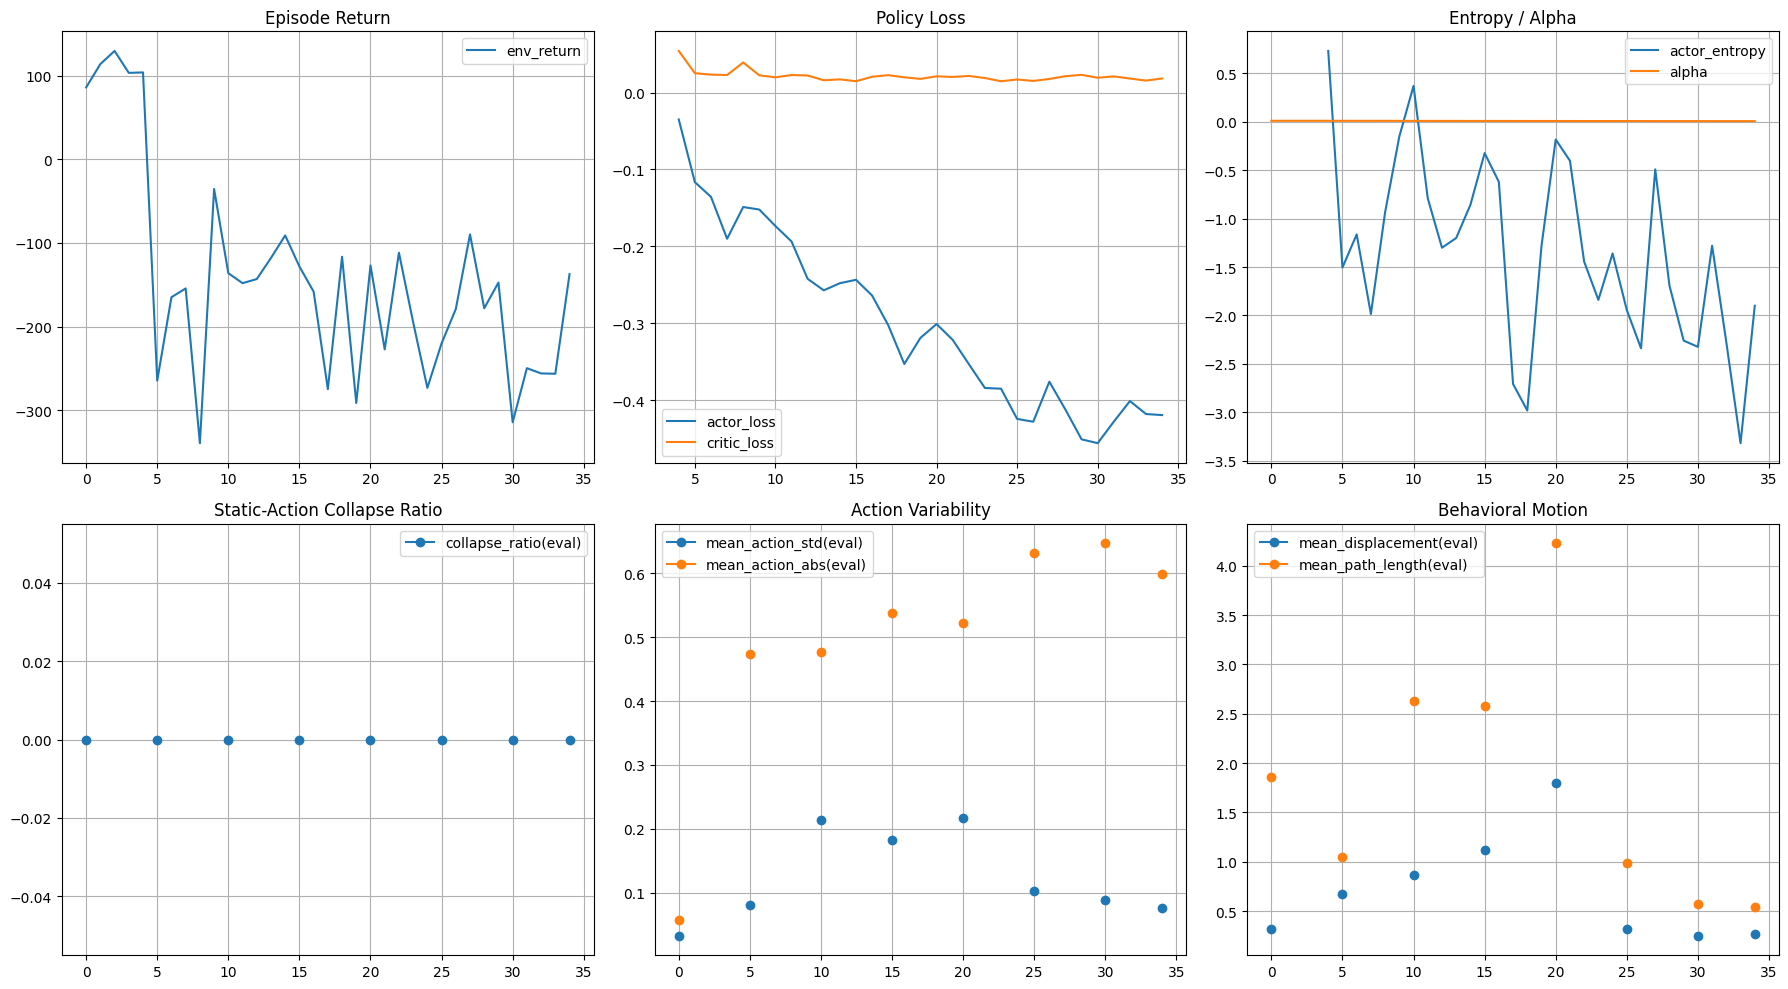


Final standard-flow verdict row:
{'episode': 34.0, 'episode_length': 200.0, 'episode_env_return': -137.26713394140825, 'buffer_size': 7000.0, 'actor_loss_mean': -0.41942797042429447, 'actor_entropy_mean': -1.8994571203365922, 'critic_loss_mean': 0.018369584184256382, 'alpha_mean': 0.006578195963811595, 'collapse_ratio': 0.0, 'mean_action_std': 0.07548676617443562, 'mean_action_abs': 0.5993921123445034, 'mean_displacement': 0.265068503562361, 'mean_path_length': 0.5422665029764175}


In [9]:
import hydra
import gymnasium as gym
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf
from flash_rl.agents import create_agent

# Register hydra resolver used by the config if not yet registered in this kernel.
try:
    OmegaConf.register_new_resolver("eval", lambda s: eval(s))
except ValueError:
    pass

def _seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def _as_bool_scalar(x):
    arr = np.asarray(x)
    if arr.size == 1:
        return bool(arr.item())
    return bool(arr.reshape(-1)[0])

def _as_float_scalar(x):
    arr = np.asarray(x, dtype=np.float32)
    if arr.size == 1:
        return float(arr.item())
    return float(arr.reshape(-1)[0])

def _ensure_batch_obs(obs):
    obs = np.asarray(obs, dtype=np.float32)
    if obs.ndim == 1:
        obs = obs[None, :]
    return obs

def build_standard_metra_agent(seed=0):
    _seed_all(seed)
    config_path = "../configs"
    config_name = "metra_aligned_base"
    overrides = [
        "agent.encoder_type=gaussian",
        "agent.buffer_min_length=1000",
        "agent.sample_batch_size=256",
        "agent.use_compile=False",
        "agent.actor_update_period=1",
    ]

    if GlobalHydra.instance().is_initialized():
        GlobalHydra.instance().clear()
    hydra.initialize(version_base=None, config_path=config_path)
    cfg_std = hydra.compose(config_name=config_name, overrides=overrides)
    OmegaConf.resolve(cfg_std)

    sample_obs, env_info_std = metra_env.reset()
    sample_obs = _ensure_batch_obs(sample_obs)
    obs_dim = int(sample_obs.shape[-1])
    obs_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
    act_space = metra_env.action_space

    std_agent = create_agent(
        observation_space=obs_space,
        action_space=act_space,
        env_info=env_info_std,
        cfg=cfg_std.agent,
    )
    return std_agent, cfg_std

def collect_one_path_standard(train_env, std_agent, max_path_length=200):
    observations, _ = train_env.reset()
    observations = _ensure_batch_obs(observations)
    prev_transition = {"next_observation": observations}

    episode_return = 0.0
    episode_length = 0

    for step in range(max_path_length):
        actions = std_agent.sample_actions(step, prev_transition, training=True)
        actions = np.asarray(actions, dtype=np.float32)
        actions_for_env = np.squeeze(actions, axis=0) if actions.ndim > 1 and actions.shape[0] == 1 else actions

        next_observations, rewards, terminateds, truncateds, env_infos = train_env.step(actions_for_env)
        next_observations = _ensure_batch_obs(next_observations)
        next_buffer_observations = next_observations.copy()

        terminated_bool = _as_bool_scalar(terminateds)
        truncated_bool = _as_bool_scalar(truncateds)
        naturally_done = bool(terminated_bool or truncated_bool)

        if naturally_done and isinstance(env_infos, dict) and "final_obs" in env_infos:
            final_obs = _ensure_batch_obs(env_infos["final_obs"])
            next_buffer_observations = final_obs

        at_path_limit = (step == max_path_length - 1)
        effective_truncateds = truncated_bool
        if at_path_limit and not terminated_bool:
            effective_truncateds = True

        transition = {
            "observation": observations,
            "action": np.asarray(actions_for_env, dtype=np.float32),
            "reward": np.asarray([_as_float_scalar(rewards)], dtype=np.float32),
            "terminated": np.asarray([terminated_bool], dtype=np.bool_),
            "truncated": np.asarray([effective_truncateds], dtype=np.bool_),
            "next_observation": next_buffer_observations,
        }

        std_agent.process_transition(transition)
        episode_return += _as_float_scalar(rewards)
        episode_length += 1
        prev_transition = {"next_observation": next_observations}
        observations = next_observations

        if terminated_bool or effective_truncateds:
            break

    return episode_length, episode_return

def make_eval_skills(skill_dim, skill_type, num_skills=8, seed=0):
    if skill_type == "discrete":
        return np.eye(skill_dim, dtype=np.float32)[:num_skills]
    if skill_dim == 2:
        angles = np.linspace(0.0, 2.0 * np.pi, num_skills, endpoint=False, dtype=np.float32)
        return np.stack([np.cos(angles), np.sin(angles)], axis=1)
    rng = np.random.default_rng(seed)
    skills = rng.standard_normal((num_skills, skill_dim), dtype=np.float32)
    return skills / np.clip(np.linalg.norm(skills, axis=1, keepdims=True), 1e-8, None)

def eval_policy_collapse(std_agent, env, *, num_skills=8, horizon=200, seed=0, static_std_threshold=0.02):
    skill_dim = int(std_agent._cfg.skill_dim)
    skill_type = str(std_agent._cfg.skill_type)
    skills = make_eval_skills(skill_dim, skill_type, num_skills=num_skills, seed=seed)

    rows = []
    for sid, skill in enumerate(skills):
        std_agent.set_eval_skills(skill[None, :], normalize=(skill_type == "continuous"))
        observations, _ = env.reset()
        observations = _ensure_batch_obs(observations)
        prev_transition = {"next_observation": observations}

        actions_all = []
        positions = []

        for t in range(horizon):
            action = std_agent.sample_actions(t, prev_transition, training=False)
            action = np.asarray(action, dtype=np.float32)
            action = np.squeeze(action, axis=0) if action.ndim > 1 and action.shape[0] == 1 else action
            next_obs, reward, truncated, terminated, info = env.step(action)
            next_obs = _ensure_batch_obs(next_obs)

            obs_vec = next_obs[0]
            positions.append(np.asarray(obs_vec[:2], dtype=np.float32))
            actions_all.append(action)

            prev_transition = {"next_observation": next_obs}

            if _as_bool_scalar(truncated) or _as_bool_scalar(terminated):
                break

        actions_all = np.asarray(actions_all, dtype=np.float32)
        positions = np.asarray(positions, dtype=np.float32)

        mean_action_std = float(actions_all.std(axis=0).mean()) if len(actions_all) > 0 else 0.0
        mean_action_abs = float(np.abs(actions_all).mean()) if len(actions_all) > 0 else 0.0
        displacement = float(np.linalg.norm(positions[-1] - positions[0])) if len(positions) >= 2 else 0.0
        path_length = float(np.linalg.norm(np.diff(positions, axis=0), axis=1).sum()) if len(positions) >= 2 else 0.0

        rows.append({
            "skill_id": sid,
            "num_steps": int(len(actions_all)),
            "mean_action_std": mean_action_std,
            "mean_action_abs": mean_action_abs,
            "displacement": displacement,
            "path_length": path_length,
            "is_static": bool(mean_action_std < static_std_threshold),
        })

    eval_df = pd.DataFrame(rows)
    summary = {
        "collapse_ratio": float(eval_df["is_static"].mean()),
        "mean_action_std": float(eval_df["mean_action_std"].mean()),
        "mean_action_abs": float(eval_df["mean_action_abs"].mean()),
        "mean_displacement": float(eval_df["displacement"].mean()),
        "mean_path_length": float(eval_df["path_length"].mean()),
    }
    return summary, eval_df

# --------------------- Standard METRA Flow Experiment ---------------------
standard_seed = 0
standard_episodes = 35
standard_updates_per_episode = 64
standard_eval_every = 5
standard_num_skills = 8
standard_horizon = 200

standard_agent, standard_cfg = build_standard_metra_agent(seed=standard_seed)
standard_logs = []
standard_eval_rows = []

for ep in tqdm(range(standard_episodes), desc="standard_metra_train"):
    ep_len, ep_ret = collect_one_path_standard(
        metra_env,
        standard_agent,
        max_path_length=200,
    )

    update_infos = []
    if standard_agent._replay_buffer.can_sample():
        for _ in range(standard_updates_per_episode):
            info = standard_agent.update()
            update_infos.append(info)

    actor_losses = [float(x.get("actor/loss", np.nan)) for x in update_infos] if update_infos else [np.nan]
    actor_entropies = [float(x.get("actor/entropy", np.nan)) for x in update_infos] if update_infos else [np.nan]
    critic_losses = [float(x.get("critic/loss", np.nan)) for x in update_infos] if update_infos else [np.nan]
    alphas = [float(x.get("temperature/value", np.nan)) for x in update_infos] if update_infos else [float(standard_agent._temperature().item())]

    row = {
        "episode": ep,
        "episode_length": float(ep_len),
        "episode_env_return": float(ep_ret),
        "buffer_size": float(len(standard_agent._replay_buffer)),
        "actor_loss_mean": float(np.nanmean(actor_losses)),
        "actor_entropy_mean": float(np.nanmean(actor_entropies)),
        "critic_loss_mean": float(np.nanmean(critic_losses)),
        "alpha_mean": float(np.nanmean(alphas)),
    }

    if (ep % standard_eval_every == 0) or (ep == standard_episodes - 1):
        eval_summary, eval_df = eval_policy_collapse(
            standard_agent,
            metra_env,
            num_skills=standard_num_skills,
            horizon=standard_horizon,
            seed=standard_seed,
            static_std_threshold=0.02,
        )
        row.update(eval_summary)
        eval_df = eval_df.copy()
        eval_df["episode"] = ep
        standard_eval_rows.append(eval_df)
    else:
        row.update({
            "collapse_ratio": np.nan,
            "mean_action_std": np.nan,
            "mean_action_abs": np.nan,
            "mean_displacement": np.nan,
            "mean_path_length": np.nan,
        })

    standard_logs.append(row)

standard_df = pd.DataFrame(standard_logs)
standard_eval_df = pd.concat(standard_eval_rows, ignore_index=True) if len(standard_eval_rows) > 0 else pd.DataFrame()

display(standard_df.tail(10))
display(standard_eval_df.tail(16))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

axes[0].plot(standard_df["episode"], standard_df["episode_env_return"], label="env_return")
axes[0].set_title("Episode Return")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(standard_df["episode"], standard_df["actor_loss_mean"], label="actor_loss")
axes[1].plot(standard_df["episode"], standard_df["critic_loss_mean"], label="critic_loss")
axes[1].set_title("Policy Loss")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(standard_df["episode"], standard_df["actor_entropy_mean"], label="actor_entropy")
axes[2].plot(standard_df["episode"], standard_df["alpha_mean"], label="alpha")
axes[2].set_title("Entropy / Alpha")
axes[2].grid(True)
axes[2].legend()

axes[3].plot(standard_df["episode"], standard_df["collapse_ratio"], marker="o", label="collapse_ratio(eval)")
axes[3].set_title("Static-Action Collapse Ratio")
axes[3].grid(True)
axes[3].legend()

axes[4].plot(standard_df["episode"], standard_df["mean_action_std"], marker="o", label="mean_action_std(eval)")
axes[4].plot(standard_df["episode"], standard_df["mean_action_abs"], marker="o", label="mean_action_abs(eval)")
axes[4].set_title("Action Variability")
axes[4].grid(True)
axes[4].legend()

axes[5].plot(standard_df["episode"], standard_df["mean_displacement"], marker="o", label="mean_displacement(eval)")
axes[5].plot(standard_df["episode"], standard_df["mean_path_length"], marker="o", label="mean_path_length(eval)")
axes[5].set_title("Behavioral Motion")
axes[5].grid(True)
axes[5].legend()

plt.tight_layout()
plt.show()

print("\nFinal standard-flow verdict row:")
print(standard_df.iloc[-1].to_dict())

In [10]:
encoder_metric_cols = [
    "episode",
    "reward_abs_mean",
    "reward_mean",
    "squared_dist_mean",
    "constraint_mean",
    "encoder_loss",
    "dual_lambda",
    "dual_lambda_loss",
    "critic_1_loss",
    "critic_2_loss",
    "actor_loss",
    "alpha",
    "q_mean",
    "log_prob_mean",
]

encoder_summary = train_df[encoder_metric_cols].copy()
display(encoder_summary.tail(10))

encoder_agg = encoder_summary.drop(columns=["episode"]).agg(["mean", "std", "min", "max"]).T
display(encoder_agg)

print("\nEncoder metrics final row:")
print(encoder_summary.iloc[-1].to_dict())

,episode,reward_abs_mean,reward_mean,squared_dist_mean,constraint_mean,encoder_loss,dual_lambda,dual_lambda_loss,critic_1_loss,critic_2_loss,actor_loss,alpha,q_mean,log_prob_mean
30,30,0.284925,0.003922,0.118589,0.000989,-0.024646,24.848869,0.003065,0.046487,0.052720,-2.088887,0.005103,1.859978,-44.847549
31,31,0.266962,0.004625,0.103417,0.001000,-0.026045,24.692190,0.003171,0.045329,0.054120,-2.115471,0.004995,1.889671,-45.188584
32,32,0.251453,0.007339,0.097102,0.000969,-0.026475,24.542255,0.002879,0.051398,0.057833,-2.147983,0.004890,1.925119,-45.556868
33,33,0.273625,0.008651,0.117014,0.000981,-0.029103,24.394741,0.003050,0.047424,0.054113,-2.182462,0.004788,1.962881,-45.846654
34,34,0.281133,0.005465,0.121637,0.000998,-0.026080,24.241927,0.003103,0.043643,0.048625,-2.206000,0.004688,1.989912,-46.080052
35,35,0.261821,0.005940,0.101886,0.001000,-0.026166,24.091401,0.003039,0.044108,0.048137,-2.243351,0.004590,2.030141,-46.434400
36,36,0.252895,0.003576,0.097836,0.001000,-0.024251,23.939979,0.003113,0.038936,0.042016,-2.263218,0.004495,2.053354,-46.676958
37,37,0.247794,0.004513,0.092771,0.000997,-0.024889,23.788711,0.003096,0.036766,0.041370,-2.288105,0.004401,2.081474,-46.932361
38,38,0.270089,0.006656,0.109802,0.001000,-0.026742,23.638183,0.003065,0.035584,0.037313,-2.339786,0.004310,2.136343,-47.185545
39,39,0.268271,0.006362,0.113184,0.001000,-0.026336,23.489423,0.003074,0.038388,0.040674,-2.364071,0.004221,2.163810,-47.428544


,mean,std,min,max
reward_abs_mean,0.271901,0.020704,0.242628,0.356008
reward_mean,0.009132,0.003268,0.001422,0.016106
squared_dist_mean,0.107019,0.010941,0.087136,0.130867
constraint_mean,0.000993,0.000011,0.000949,0.001000
encoder_loss,-0.031356,0.004186,-0.040533,-0.024219
dual_lambda,26.579734,1.916905,23.489423,29.903529
dual_lambda_loss,0.003123,0.000128,0.002814,0.003370
critic_1_loss,0.066245,0.077385,0.035584,0.539134
critic_2_loss,0.074256,0.083850,0.035695,0.585275
actor_loss,-1.587789,0.586428,-2.364071,-0.202988



Encoder metrics final row:
{'episode': 39.0, 'reward_abs_mean': 0.26827148883603513, 'reward_mean': 0.006361548508721171, 'squared_dist_mean': 0.11318420001771301, 'constraint_mean': 0.0010000000474974513, 'encoder_loss': -0.026336335671658162, 'dual_lambda': 23.489423006772995, 'dual_lambda_loss': 0.003074214540902176, 'critic_1_loss': 0.03838809602893889, 'critic_2_loss': 0.04067386966198683, 'actor_loss': -2.3640712574124336, 'alpha': 0.004221044000587426, 'q_mean': 2.163809511810541, 'log_prob_mean': -47.42854392528534}
